# Popular Recommender

In this notebook, we build and evaluate three non-personalized popularity recommenders for wines:

- most popular overall
- most popular by country of origin
- most popular by wine type (red, white, rose, etc.)

Metrics that we use in this notebook are:

- Accuracy@K
- NDCG@K
- Diversity
- Personalisation
- Coverage


## 1) Environment setup and robust data loading

In [86]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
from datetime import datetime, timezone


plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [87]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for c in [start, *start.parents]:
        if (c / 'dataset').exists() and (c / 'EDA').exists():
            return c
    raise FileNotFoundError('Project root with dataset/ and EDA/ not found')

PROJECT_ROOT = find_project_root(Path.cwd())
DATASET_DIR = PROJECT_ROOT / 'dataset'
RESULTS_DIR = PROJECT_ROOT / 'data' / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

wines = pd.read_csv(
    DATASET_DIR / 'XWines_Full_100K_wines.csv',
    usecols=['WineID', 'WineName', 'Type', 'Country', 'RegionName'],
    dtype={'WineID': 'int32', 'WineName': 'string', 'Type': 'category', 'Country': 'category', 'RegionName': 'string'}
)

ratings = pd.read_csv(
    DATASET_DIR / 'XWines_Full_21M_ratings.csv',
    usecols=['UserID', 'WineID', 'Rating'],
    dtype={'UserID': 'int32', 'WineID': 'int32', 'Rating': 'float32'}
)

wines = wines.drop_duplicates(subset='WineID').copy()
ratings = ratings.drop_duplicates(subset=['UserID', 'WineID']).copy()
ratings = ratings[ratings['WineID'].isin(wines['WineID'])].copy()

print('wines:', wines.shape)
print('ratings:', ratings.shape)
print('users:', ratings['UserID'].nunique())
print('items:', ratings['WineID'].nunique())


wines: (100646, 5)
ratings: (20590800, 3)
users: 1056079
items: 100646


## 2) EDA recap for popularity modeling

In this section, we will have again a look at our data distribution, the ratings and items popularity. We have presenteed the thorough analysis of this in the EDA notebook, and here we just mention it to have another look. 

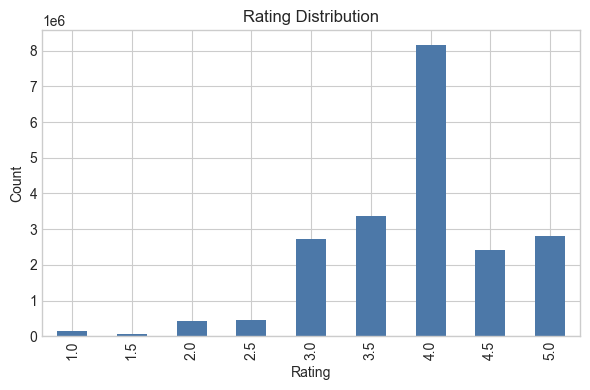

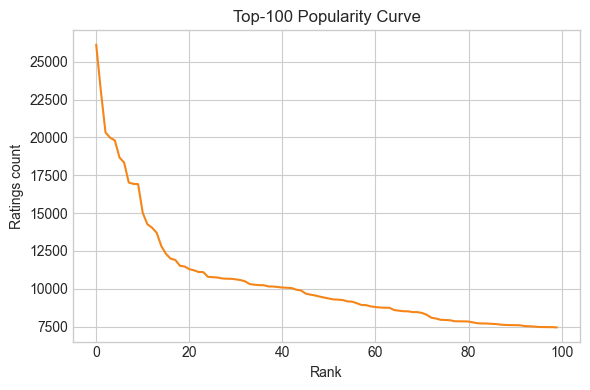

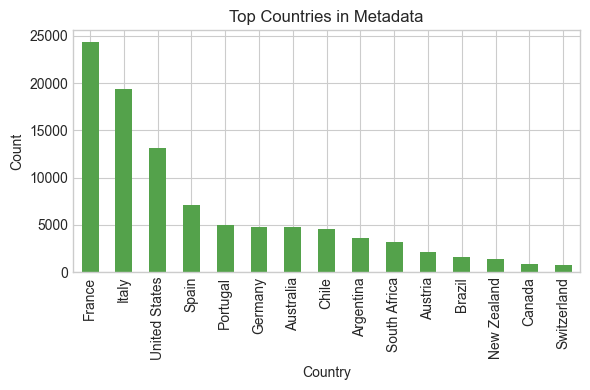

In [88]:
# --- Plot 1: Rating Distribution ---
plt.figure(figsize=(6, 4))
ratings['Rating'].value_counts().sort_index().plot(kind='bar', color='#4C78A8')

plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


# --- Plot 2: Top-100 Popularity Curve ---
plt.figure(figsize=(6, 4))
item_pop = ratings['WineID'].value_counts()

item_pop.head(100).reset_index(drop=True).plot(color='#F58518')

plt.title('Top-100 Popularity Curve')
plt.xlabel('Rank')
plt.ylabel('Ratings count')

plt.tight_layout()
plt.show()


# --- Plot 3: Top Countries in Metadata ---
plt.figure(figsize=(6, 4))
wines['Country'].value_counts().head(15).plot(kind='bar', color='#54A24B')

plt.title('Top Countries in Metadata')
plt.xlabel('Country')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

As we saw before, the rating dostribution is skewed to the right, and we see more posisitve ratings, with the average at aprx 4. 

The graph shows that a small number of items receive a very high number of ratings, while most items have much fewer ratings.

Moreover, we can observe the most popular countries: France, Italy, and the US. 

## 3) Positive interactions and CVTT split

Here we first keep only positive ratings, then filter the users so that only those with a reasonable number of interactions remain in the dataset. After that, we randomly sample up to 5000 users, split each user’s data into training-validation and test sets, and assign fold IDs for cross-validation.

In [89]:
POSITIVE_THRESHOLD = 4.0
MIN_POSITIVE_INTERACTIONS = 5
MAX_POSITIVE_INTERACTIONS = 250
MAX_USERS = 5000
SAMPLED_USERS_PATH = RESULTS_DIR / 'nonpers_sampled_users_5000.csv'

positive = ratings[ratings['Rating'] >= POSITIVE_THRESHOLD].copy()
user_counts = positive['UserID'].value_counts()

eligible_users = user_counts[
    (user_counts >= MIN_POSITIVE_INTERACTIONS) &
    (user_counts <= MAX_POSITIVE_INTERACTIONS)
].index
positive = positive[positive['UserID'].isin(eligible_users)].copy()

if SAMPLED_USERS_PATH.exists():
    sampled_users = pd.read_csv(SAMPLED_USERS_PATH)['UserID'].to_numpy()
    sampled_users = np.intersect1d(sampled_users, positive['UserID'].unique())
else:
    rng = np.random.default_rng(RANDOM_STATE)
    sampled_users = rng.choice(
        positive['UserID'].unique(),
        size=min(MAX_USERS, positive['UserID'].nunique()),
        replace=False
    )
    pd.Series(sampled_users, name='UserID').to_csv(SAMPLED_USERS_PATH, index=False)

positive = positive[positive['UserID'].isin(sampled_users)].copy()


def split_train_test_per_user(df, test_fraction=0.2, random_state=42):
    tr, te = [], []
    for _, g in df.groupby('UserID'):
        g = g.sample(frac=1.0, random_state=random_state)
        n_test = max(1, int(np.ceil(len(g) * test_fraction)))
        te_g, tr_g = g.iloc[:n_test], g.iloc[n_test:]
        if len(tr_g) == 0:
            continue
        tr.append(tr_g)
        te.append(te_g)
    return pd.concat(tr, ignore_index=True), pd.concat(te, ignore_index=True)


def assign_fold_ids_per_user(df, n_folds=3, random_state=42):
    chunks = []
    for _, g in df.groupby('UserID'):
        g = g.sample(frac=1.0, random_state=random_state).copy()
        g['fold_id'] = np.arange(len(g)) % n_folds
        chunks.append(g)
    return pd.concat(chunks, ignore_index=True)


trainval_pos, test_pos = split_train_test_per_user(positive, test_fraction=0.2, random_state=RANDOM_STATE)
trainval_folds = assign_fold_ids_per_user(trainval_pos, n_folds=3, random_state=RANDOM_STATE)

print('trainval:', trainval_pos.shape)
print('test:', test_pos.shape)


trainval: (56673, 3)
test: (16646, 3)


## 4) Metrics used for evaluation

In order to evaluate the work that has been done, we will define he metrics below: 

- Accuracy@K
- NDCG@K
- Diversity@K
- Personalisation@10
- Coverage

In [90]:
def accuracy_at_k(relevant, recommended, k):
    rec_k = recommended[:k]
    if k == 0:
        return 0.0
    hits = sum(1 for x in rec_k if x in relevant)
    return hits / k


def dcg_at_k(relevant, recommended, k):
    s = 0.0
    for i, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            s += 1.0 / np.log2(i + 1)
    return s


def ndcg_at_k(relevant, recommended, k):
    ideal_hits = min(len(relevant), k)
    if ideal_hits == 0:
        return 0.0
    idcg = sum(1.0 / np.log2(i + 1) for i in range(1, ideal_hits + 1))
    return dcg_at_k(relevant, recommended, k) / idcg


In [91]:
item_meta = wines.set_index('WineID')[['Type', 'Country']].copy()
item_meta['Type'] = item_meta['Type'].astype(str).str.lower().fillna('unknown')
item_meta['Country'] = item_meta['Country'].astype(str).str.lower().fillna('unknown')

item_signatures = {
    wid: {f"type:{item_meta.loc[wid, 'Type']}", f"country:{item_meta.loc[wid, 'Country']}"}
    for wid in item_meta.index
}


def jaccard_distance(a, b):
    inter = len(a & b)
    union = len(a | b)
    return 0.0 if union == 0 else 1.0 - inter / union


def intra_list_diversity(recommended):
    if len(recommended) < 2:
        return 0.0
    vals = []
    for i in range(len(recommended)):
        for j in range(i + 1, len(recommended)):
            vals.append(jaccard_distance(item_signatures.get(recommended[i], {'unknown'}), item_signatures.get(recommended[j], {'unknown'})))
    return float(np.mean(vals)) if vals else 0.0


def personalisation_at_k(recs_by_user, k=10, max_users=300, random_state=42):
    users = list(recs_by_user.keys())
    if len(users) < 2:
        return 0.0

    rng = np.random.default_rng(random_state)
    if len(users) > max_users:
        users = rng.choice(users, size=max_users, replace=False).tolist()

    sets = {u: set(recs_by_user[u][:k]) for u in users}

    sims = []
    for u1, u2 in itertools.combinations(users, 2):
        a, b = sets[u1], sets[u2]
        union = len(a | b)
        sim = (len(a & b) / union) if union > 0 else 0.0
        sims.append(sim)

    if not sims:
        return 0.0
    return float(1.0 - np.mean(sims))


The function below  evaluates how well the recommender system works by generating recommendations for each user and comparing them to the items they actually liked. It calculates metrics like accuracy, ranking quality (NDCG), diversity, and also measures overall coverage and personalization of the recommendations.

In [92]:
def evaluate_model(model, recommend_fn, eval_users, relevant_dict, ks=(5, 10, 20)):
    rows = []
    recs_by_user = {}
    max_k = max(ks)
    all_top10_items = []

    for user_id in eval_users:
        relevant = relevant_dict.get(user_id, set())
        if not relevant:
            continue

        recs = recommend_fn(model, user_id, top_k=max_k)
        if len(recs) == 0:
            continue

        recs_by_user[user_id] = recs
        all_top10_items.extend(recs[:10])

        row = {'UserID': user_id}
        for k in ks:
            row[f'Accuracy@{k}'] = accuracy_at_k(relevant, recs, k)
            row[f'NDCG@{k}'] = ndcg_at_k(relevant, recs, k)
            row[f'Diversity@{k}'] = intra_list_diversity(recs[:k])
        rows.append(row)

    eval_df = pd.DataFrame(rows)
    if eval_df.empty:
        return eval_df, {}, recs_by_user

    coverage = len(set(all_top10_items)) / len(model['all_items']) if len(model['all_items']) else 0.0
    pers = personalisation_at_k(recs_by_user, k=10, max_users=300, random_state=RANDOM_STATE)

    summary_extra = {
        'Coverage': coverage,
        'Personalisation@10': pers
    }
    return eval_df, summary_extra, recs_by_user


In [106]:
def plot_model_diagnostics(
    eval_df,
    recs_by_user,
    model_name,
    top_k=10,
    model=None,
    max_users_for_personalisation=300,
    random_state=42
):
    """
    Plots diagnostics for:
    - Accuracy@K
    - NDCG@K
    - Diversity@K
    - Personalisation@K
    - Coverage
    """
    if eval_df.empty:
        print(f"No evaluation rows for {model_name}")
        return

    acc_col = f"Accuracy@{top_k}"
    ndcg_col = f"NDCG@{top_k}"
    div_col = f"Diversity@{top_k}"

    missing = [c for c in [acc_col, ndcg_col, div_col] if c not in eval_df.columns]
    if missing:
        print(f"Missing columns in eval_df: {missing}")
        return

    users = list(recs_by_user.keys())
    if len(users) == 0:
        print(f"No recommendation lists for {model_name}")
        return

    rng = np.random.default_rng(random_state)
    if len(users) > max_users_for_personalisation:
        users = rng.choice(users, size=max_users_for_personalisation, replace=False).tolist()

    user_sets = {u: set(recs_by_user[u][:top_k]) for u in users}

    personalisation_per_user = []
    coverage_per_user = []
    all_items_global = []

    for u in users:
        rec_u = recs_by_user[u][:top_k]
        all_items_global.extend(rec_u)

        # coverage per user: unique items in top_k / k
        coverage_per_user.append(len(set(rec_u)) / max(top_k, 1))

        sims = []
        for v in users:
            if u == v:
                continue
            a, b = user_sets[u], user_sets[v]
            union = len(a | b)
            sim = (len(a & b) / union) if union > 0 else 0.0
            sims.append(sim)
        personalisation_per_user.append(1.0 - np.mean(sims) if sims else 0.0)

    if model is not None and "all_items" in model:
        global_coverage = len(set(all_items_global)) / len(model["all_items"]) if len(model["all_items"]) else np.nan
    else:
        global_coverage = np.nan

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    sns.histplot(eval_df[acc_col], bins=25, kde=True, ax=axes[0], color="#4C78A8")
    axes[0].set_title(f"{model_name} - {acc_col}")

    sns.histplot(eval_df[ndcg_col], bins=25, kde=True, ax=axes[1], color="#54A24B")
    axes[1].set_title(f"{model_name} - {ndcg_col}")

    sns.histplot(eval_df[div_col], bins=25, kde=True, ax=axes[2], color="#B279A2")
    axes[2].set_title(f"{model_name} - {div_col}")

    sns.histplot(personalisation_per_user, bins=25, kde=True, ax=axes[3], color="#E45756")
    axes[3].set_title(f"{model_name} - Personalisation@{top_k}")
    axes[3].set_xlabel("personalisation score")

    sns.histplot(coverage_per_user, bins=25, kde=True, ax=axes[4], color="#72B7B2")
    axes[4].set_title(f"{model_name} - Coverage@{top_k} (per-user)")
    axes[4].set_xlabel("coverage score")

    freq = pd.Series(all_items_global).value_counts() if all_items_global else pd.Series(dtype="int64")
    if freq.empty:
        axes[5].text(0.5, 0.5, "No recs", ha="center", va="center")
    else:
        sns.histplot(freq.values, bins=30, kde=False, ax=axes[5], color="#F58518")
    axes[5].set_title(f"{model_name} - Item Frequency Histogram")
    axes[5].set_xlabel("recommendation count per item")
    axes[5].set_ylabel("number of items")

    cov_text = "Global coverage: N/A" if np.isnan(global_coverage) else f"Global coverage: {global_coverage:.4f}"
    axes[5].text(
        0.98, 0.95, cov_text,
        transform=axes[5].transAxes,
        ha="right", va="top",
        bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="gray", alpha=0.8)
    )

    plt.tight_layout()
    plt.show()


## 5) Popularity scoring function

This function calculates a popularity score for each wine by combining its average rating and how many times it was rated. It uses a weighted (Bayesian) average and a normalized popularity measure, then mixes them together to rank items more reliably.

Bayesian averaging is used to avoid overestimating items with very few ratings by pulling their scores closer to the overall average.

In [94]:
def build_popularity_scores(group_df, alpha=0.8, m=20):
    stats = group_df.groupby('WineID')['Rating'].agg(['count', 'mean']).rename(columns={'count': 'v', 'mean': 'R'})
    if stats.empty:
        return pd.DataFrame(columns=['WineID', 'score'])

    C = float(group_df['Rating'].mean())
    stats['bayes'] = (stats['v'] / (stats['v'] + m)) * stats['R'] + (m / (stats['v'] + m)) * C

    log_v = np.log1p(stats['v'])
    if float(log_v.max()) > float(log_v.min()):
        pop_norm = (log_v - log_v.min()) / (log_v.max() - log_v.min())
    else:
        pop_norm = pd.Series(0.0, index=stats.index)

    stats['score'] = alpha * stats['bayes'] + (1 - alpha) * pop_norm
    return stats[['score']].reset_index().sort_values('score', ascending=False)


## 6) Build popular recommenders

In this section, we will build the popular recommenders with simple personalization. It ranks wines based on how popular they are (globally, by country, and by type), then recommends items to users while avoiding ones they have already seen and using their preferences (country/type) when possible.

This function builds the popularity-based recommendation model. It calculates global popularity rankings, as well as popularity rankings by country and wine type, and also identifies each user’s preferred country and type based on their past interactions.

In [95]:
def fit_popular_family(train_df, wines_df, alpha=0.8, m=20, min_group_items=20):
    train_seen = train_df.groupby('UserID')['WineID'].apply(set).to_dict()
    merged = train_df.merge(wines_df[['WineID', 'Type', 'Country']], on='WineID', how='left')

    global_rank = build_popularity_scores(merged[['WineID', 'Rating']], alpha=alpha, m=m)['WineID'].tolist()

    by_country = {}
    for country, g in merged.groupby('Country'):
        ranked = build_popularity_scores(g[['WineID', 'Rating']], alpha=alpha, m=m)['WineID'].tolist()
        if len(ranked) >= min_group_items:
            by_country[country] = ranked

    by_type = {}
    for wine_type, g in merged.groupby('Type'):
        ranked = build_popularity_scores(g[['WineID', 'Rating']], alpha=alpha, m=m)['WineID'].tolist()
        if len(ranked) >= min_group_items:
            by_type[wine_type] = ranked

    user_pref_country = (
        merged.groupby(['UserID', 'Country']).size().reset_index(name='n')
        .sort_values(['UserID', 'n'], ascending=[True, False])
        .drop_duplicates('UserID')
        .set_index('UserID')['Country']
        .to_dict()
    )

    user_pref_type = (
        merged.groupby(['UserID', 'Type']).size().reset_index(name='n')
        .sort_values(['UserID', 'n'], ascending=[True, False])
        .drop_duplicates('UserID')
        .set_index('UserID')['Type']
        .to_dict()
    )

    return {
        'global_rank': global_rank,
        'country_rank': by_country,
        'type_rank': by_type,
        'user_pref_country': user_pref_country,
        'user_pref_type': user_pref_type,
        'train_seen': train_seen,
        'all_items': np.array(sorted(wines_df['WineID'].unique())),
    }





This helper function removes items that the user has already interacted with. It returns the top-k unseen items from a ranked list.

In [96]:
def _filter_seen(ranked_items, seen, top_k):
    out = []
    for w in ranked_items:
        if w not in seen:
            out.append(int(w))
        if len(out) >= top_k:
            break
    return out

### 6.1) Build overall popular recommender

This function recommends the most popular wines overall, ignoring personalization. It simply returns the top-ranked global items that the user has not already seen.

In [97]:

def recommend_popular_global(model, user_id, top_k=10):
    seen = model['train_seen'].get(user_id, set())
    return _filter_seen(model['global_rank'], seen, top_k)

### 6.2) Build popular recommender by country

This function recommends wines based on the user’s preferred country. If there are not enough recommendations from that country, it fills the remaining slots using globally popular wines.

In [98]:
def recommend_popular_country(model, user_id, top_k=10):
    seen = model['train_seen'].get(user_id, set())
    pref_country = model['user_pref_country'].get(user_id)
    ranked = model['country_rank'].get(pref_country, model['global_rank'])
    recs = _filter_seen(ranked, seen, top_k)
    if len(recs) < top_k:
        recs.extend(_filter_seen(model['global_rank'], seen.union(recs), top_k - len(recs)))
    return recs[:top_k]



### 6.3) Build popular recommender by wine type

This function works similarly to the country-based one, but instead uses the user’s preferred wine type. It also falls back to global popularity if needed.

In [99]:
def recommend_popular_type(model, user_id, top_k=10):
    seen = model['train_seen'].get(user_id, set())
    pref_type = model['user_pref_type'].get(user_id)
    ranked = model['type_rank'].get(pref_type, model['global_rank'])
    recs = _filter_seen(ranked, seen, top_k)
    if len(recs) < top_k:
        recs.extend(_filter_seen(model['global_rank'], seen.union(recs), top_k - len(recs)))
    return recs[:top_k]

## 7) Hyperparameter tuning with CV and early stopping

In this section, we will tune two hyperparameters: alpha and m.

Alpha controls how much we rely on the average rating versus how popular an item is, while m controls how strongly we smooth the ratings using the global average, especially for items with few ratings.

In [100]:
def build_fold_split(df_with_folds, fold_id):
    tr = df_with_folds[df_with_folds['fold_id'] != fold_id].drop(columns='fold_id').copy()
    va = df_with_folds[df_with_folds['fold_id'] == fold_id].drop(columns='fold_id').copy()
    return tr, va


def relevant_dict_from_df(df):
    return df.groupby('UserID')['WineID'].apply(set).to_dict()


def tune_popular(trainval_folds_df, alpha_grid=(0.65, 0.75, 0.85, 0.95), m_grid=(5, 10, 20, 50), min_group_items=20, n_folds=3, patience=3):
    best_params, best_score = None, -np.inf
    bad_rounds = 0
    rows = []

    for alpha in alpha_grid:
        for m in m_grid:
            fold_scores = []
            for fold in range(n_folds):
                tr, va = build_fold_split(trainval_folds_df, fold)
                model = fit_popular_family(tr, wines, alpha=alpha, m=m, min_group_items=min_group_items)
                va_rel = relevant_dict_from_df(va)
                eval_users = sorted(set(model['train_seen'].keys()) & set(va_rel.keys()))
                eval_df, _, _ = evaluate_model(model, recommend_popular_global, eval_users, va_rel, ks=(10,))
                fold_scores.append(eval_df['NDCG@10'].mean() if not eval_df.empty else 0.0)

            mean_score = float(np.mean(fold_scores))
            rows.append({'alpha': alpha, 'm': m, 'cv_ndcg@10': mean_score})

            if mean_score > best_score:
                best_score = mean_score
                best_params = {'alpha': alpha, 'm': m}
                bad_rounds = 0
            else:
                bad_rounds += 1

            if bad_rounds >= patience:
                print(f'Early stopping at alpha={alpha}, m={m}')
                return pd.DataFrame(rows), best_params, best_score

    return pd.DataFrame(rows), best_params, best_score


tuning_df, best_params, best_cv = tune_popular(trainval_folds, n_folds=3, patience=3)
display(tuning_df)
print('best_params:', best_params)
print('best_cv_ndcg@10:', round(best_cv, 6))


Early stopping at alpha=0.75, m=20


,alpha,m,cv_ndcg@10
0,0.65,5,0.004762
1,0.65,10,0.005238
2,0.65,20,0.006127
3,0.65,50,0.006529
4,0.75,5,0.004300
5,0.75,10,0.004801
6,0.75,20,0.005593


best_params: {'alpha': 0.65, 'm': 50}
best_cv_ndcg@10: 0.006529


This result shows that the best performance was achieved with alpha = 0.65 and m = 50, since this combination gave the highest NDCG@10 score. This means the model works better when it gives slightly more importance to popularity and uses stronger smoothing to avoid unreliable ratings.

The early stopping happened at alpha = 0.75 and m = 20 because the model stopped improving, so it did not continue testing further combinations.

In [101]:
final_model = fit_popular_family(
    trainval_pos,
    wines,
    alpha=float(best_params['alpha']),
    m=int(best_params['m']),
    min_group_items=20
)

test_relevant = test_pos.groupby('UserID')['WineID'].apply(set).to_dict()
eval_users = sorted(set(final_model['train_seen'].keys()) & set(test_relevant.keys()))
print('evaluation users:', len(eval_users))


evaluation users: 5000


## 8) Most popular overall

In [102]:
global_eval_df, global_extra, global_recs_by_user = evaluate_model(
    final_model,
    recommend_popular_global,
    eval_users,
    test_relevant,
    ks=(5, 10, 20)
)

global_summary = global_eval_df.drop(columns='UserID').mean().to_dict()
global_summary.update(global_extra)
global_summary = pd.DataFrame([global_summary], index=['PopularGlobal'])
display(global_summary)


,Accuracy@5,NDCG@5,Diversity@5,Accuracy@10,NDCG@10,Diversity@10,Accuracy@20,NDCG@20,Diversity@20,Coverage,Personalisation@10
PopularGlobal,0.00468,0.006596,0.698213,0.004,0.008424,0.665846,0.00315,0.010756,0.639617,0.000169,0.025232


The Popular global recommender achieves slightly better accuracy and NDCG than the random model, which shows that recommending the most popular items can capture some user preferences. However, the performance is still quite low, meaning it does not personalize well and mostly recommends the same items to everyone.

The diversity and especially the personalisation scores are low, and the coverage is extremely small, which indicates that the model keeps recommending a very limited set of popular items. Overall, this model is simple and stable, but it lacks personalization and tends to over-focus on a few popular wines.

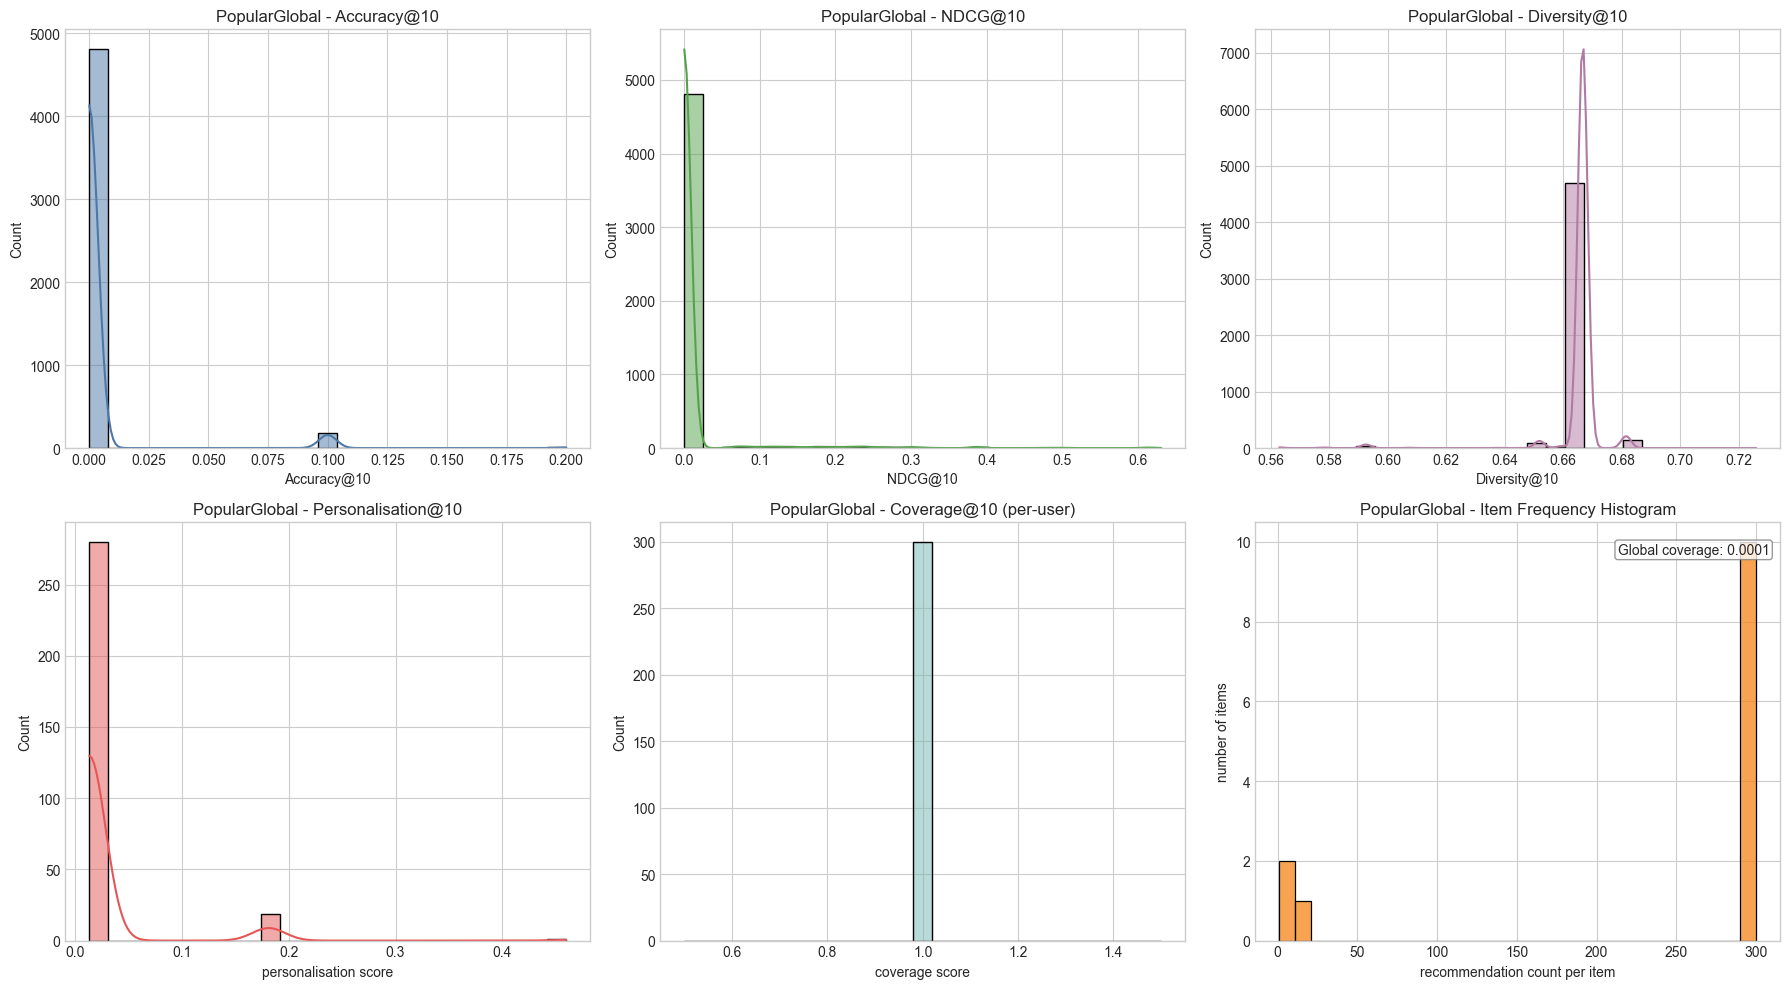

In [107]:
plot_model_diagnostics(
    global_eval_df,
    global_recs_by_user,
    model_name='PopularGlobal',
    top_k=10,
    model=final_model
)


These graphs show that most users get very low accuracy and NDCG, meaning the recommendations are usually not relevant. At the same time, diversity is similar for everyone, and personalisation is very low, which means users are mostly getting the same recommendations.

The coverage is also extremely low, and the item frequency graph shows that only a few items are recommended many times. Overall, the model keeps recommending the same popular items to everyone and does not adapt well to individual users.

### Qualitative examples: 3 users for global popularity

In [ ]:
example_users_global = sorted(global_recs_by_user.keys())[:3]
print('Example users:', example_users_global)

for user_id in example_users_global:
    recs = recommend_popular_global(final_model, user_id, top_k=10)
    print(f'\nUser {user_id}')
    display(
        wines[wines['WineID'].isin(recs)][['WineID', 'WineName', 'Type', 'Country']]
        .set_index('WineID')
        .loc[recs]
    )


Example users: [1000404, 1001240, 1001312]

User 1000404


,WineName,Type,Country
WineID,,,
179012,Cabernet Sauvignon,Red,United States
111391,Brut Champagne,Sparkling,France
135825,Tignanello,Red,Italy
179014,Opus One,Red,United States
111395,Pauillac (Premier Grand Cru Classé),Red,France
135826,Sassicaia,Red,Italy
162499,Almaviva,Red,Chile
167421,Malbec Alta,Red,Argentina
179013,Red Blend,Red,United States



User 1001240


,WineName,Type,Country
WineID,,,
179012,Cabernet Sauvignon,Red,United States
111391,Brut Champagne,Sparkling,France
135825,Tignanello,Red,Italy
179014,Opus One,Red,United States
111395,Pauillac (Premier Grand Cru Classé),Red,France
135826,Sassicaia,Red,Italy
162499,Almaviva,Red,Chile
167421,Malbec Alta,Red,Argentina
179013,Red Blend,Red,United States



User 1001312


,WineName,Type,Country
WineID,,,
179012,Cabernet Sauvignon,Red,United States
111391,Brut Champagne,Sparkling,France
179014,Opus One,Red,United States
111395,Pauillac (Premier Grand Cru Classé),Red,France
135826,Sassicaia,Red,Italy
162499,Almaviva,Red,Chile
167421,Malbec Alta,Red,Argentina
179013,Red Blend,Red,United States
155290,Valbuena 5º,Red,Spain


The recommendations for all three users are almost identical, which shows that the global recommender suggests the same popular wines to everyone. This means it does not personalize recommendations and focuses only on the most popular items, regardless of individual user preferences.


The predictions are a bit different because the model removes items that each user has already seen. So even though the ranking is the same, small differences appear depending on what each user has already interacted with.


## 9) Most popular by country of origin

In [ ]:
country_eval_df, country_extra, country_recs_by_user = evaluate_model(
    final_model,
    recommend_popular_country,
    eval_users,
    test_relevant,
    ks=(5, 10, 20)
)

country_summary = country_eval_df.drop(columns='UserID').mean().to_dict()
country_summary.update(country_extra)
country_summary = pd.DataFrame([country_summary], index=['PopularByCountry'])
display(country_summary)


,Accuracy@5,NDCG@5,Diversity@5,Accuracy@10,NDCG@10,Diversity@10,Accuracy@20,NDCG@20,Diversity@20,Coverage,Personalisation@10
PopularByCountry,0.01004,0.015353,0.1236,0.00802,0.018864,0.112646,0.00594,0.022558,0.118425,0.00307,0.857921


The Popular by Country model performs better than the global one, since accuracy and NDCG are higher, which means it captures some user preferences by recommending wines from their preferred country. This shows that even simple personalization can improve recommendation quality.

However, diversity is much lower because the model focuses on a smaller group of items within each country, and coverage is still quite low. The personalisation score is high, but this mainly reflects that different users get different country-based lists, not necessarily that the recommendations are highly accurate.


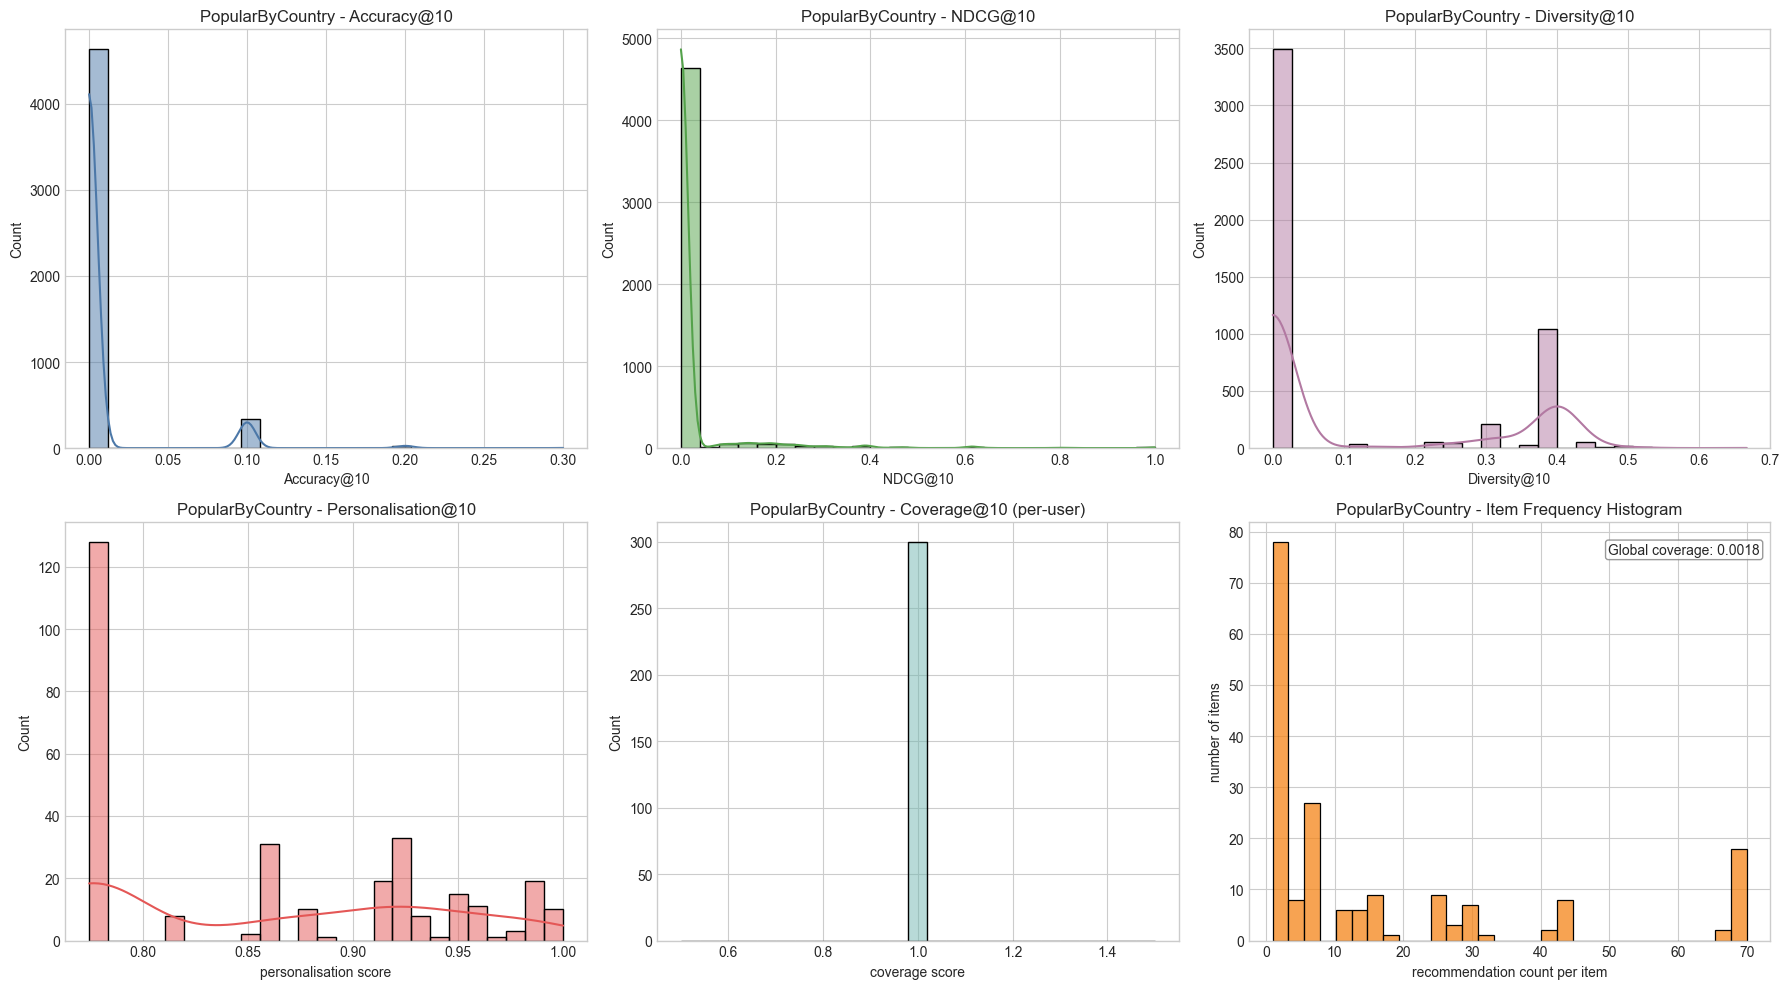

In [108]:
plot_model_diagnostics(country_eval_df, country_recs_by_user, "PopularByCountry", top_k=10, model=final_model)


These graphs show that the model performs slightly better than the global one, but most users still have very low accuracy and NDCG, meaning recommendations are often not very relevant. However, compared to before, some users now get better results because the model uses their preferred country.

The personalisation is much higher, which means different users receive different recommendations, but diversity is lower since the model focuses on a smaller set of wines within each country. Coverage is still low, and the item frequency graph shows that some items are recommended much more often than others, so the model still relies heavily on popular wines within each country.

### Qualitative examples: 3 countries

In [ ]:
train_with_country = trainval_pos.merge(wines[['WineID', 'Country']], on='WineID', how='left')
country_support = train_with_country['Country'].value_counts()

example_countries = [c for c in country_support.index if c in final_model['country_rank']][:3]
print('Example countries:', example_countries)

for country in example_countries:
    recs = final_model['country_rank'][country][:10]
    print(f'\nCountry: {country}')
    display(
        wines[wines['WineID'].isin(recs)][['WineID', 'WineName', 'Type', 'Country']]
        .set_index('WineID')
        .loc[recs]
    )


Example countries: ['France', 'Italy', 'United States']

Country: France


,WineName,Type,Country
WineID,,,
111391,Brut Champagne,Sparkling,France
111395,Pauillac (Premier Grand Cru Classé),Red,France
111402,Cristal Brut Champagne (Millésimé),Sparkling,France
111401,Sauternes,Dessert,France
111393,Brut (Carte Jaune) Champagne,Sparkling,France
111413,Grand Vin Pauillac (Premier Grand Cru Classé),Red,France
111422,Pauillac (Grand Cru Classé),Red,France
111400,Pauillac (Grand Cru Classé),Red,France
111403,Château Margaux (Premier Grand Cru Classé),Red,France



Country: Italy


,WineName,Type,Country
WineID,,,
135825,Tignanello,Red,Italy
135826,Sassicaia,Red,Italy
135828,60 Sessantanni Old Vines Primitivo di Manduria,Red,Italy
135837,Edizione Cinque Autoctoni,Red,Italy
135827,Costasera Amarone della Valpolicella Classico,Red,Italy
135841,Bolgheri Superiore,Red,Italy
135833,Brunello di Montalcino,Red,Italy
135843,Brunello di Montalcino,Red,Italy
135829,Ripassa Valpolicella Ripasso Superiore,Red,Italy



Country: United States


,WineName,Type,Country
WineID,,,
179012,Cabernet Sauvignon,Red,United States
179014,Opus One,Red,United States
179013,Red Blend,Red,United States
179038,Cabernet Sauvignon,Red,United States
179011,Pinot Noir,Red,United States
179016,ARTEMIS Cabernet Sauvignon,Red,United States
179010,Red (Winemaker's Blend),Red,United States
179043,Special Selection Cabernet Sauvignon,Red,United States
179042,Clark & Telephone Vineyard Pinot Noir,Red,United States


These recommendations show that each user gets wines mainly from their preferred country, which means the model is using country-based personalization. However, within each country, the same popular wines are repeated, so the model still relies heavily on popularity and does not provide much variety.


## 10) Most popular by wine type

In [ ]:
type_eval_df, type_extra, type_recs_by_user = evaluate_model(
    final_model,
    recommend_popular_type,
    eval_users,
    test_relevant,
    ks=(5, 10, 20)
)

type_summary = type_eval_df.drop(columns='UserID').mean().to_dict()
type_summary.update(type_extra)
type_summary = pd.DataFrame([type_summary], index=['PopularByType'])
display(type_summary)


,Accuracy@5,NDCG@5,Diversity@5,Accuracy@10,NDCG@10,Diversity@10,Accuracy@20,NDCG@20,Diversity@20,Coverage,Personalisation@10
PopularByType,0.00412,0.005723,0.52856,0.00374,0.007598,0.574987,0.00328,0.010558,0.548592,0.000755,0.199982


The Popular by Type model performs slightly better than the global model, but the accuracy and NDCG are still very low, which means it does not match user preferences very well. It uses some personalization by recommending wines of a preferred type, but this is still quite limited.

The diversity is higher than the country-based model, but personalisation is much lower, meaning many users still receive similar recommendations. Coverage is also very low, showing that the model still focuses on a small group of popular wines within each type.


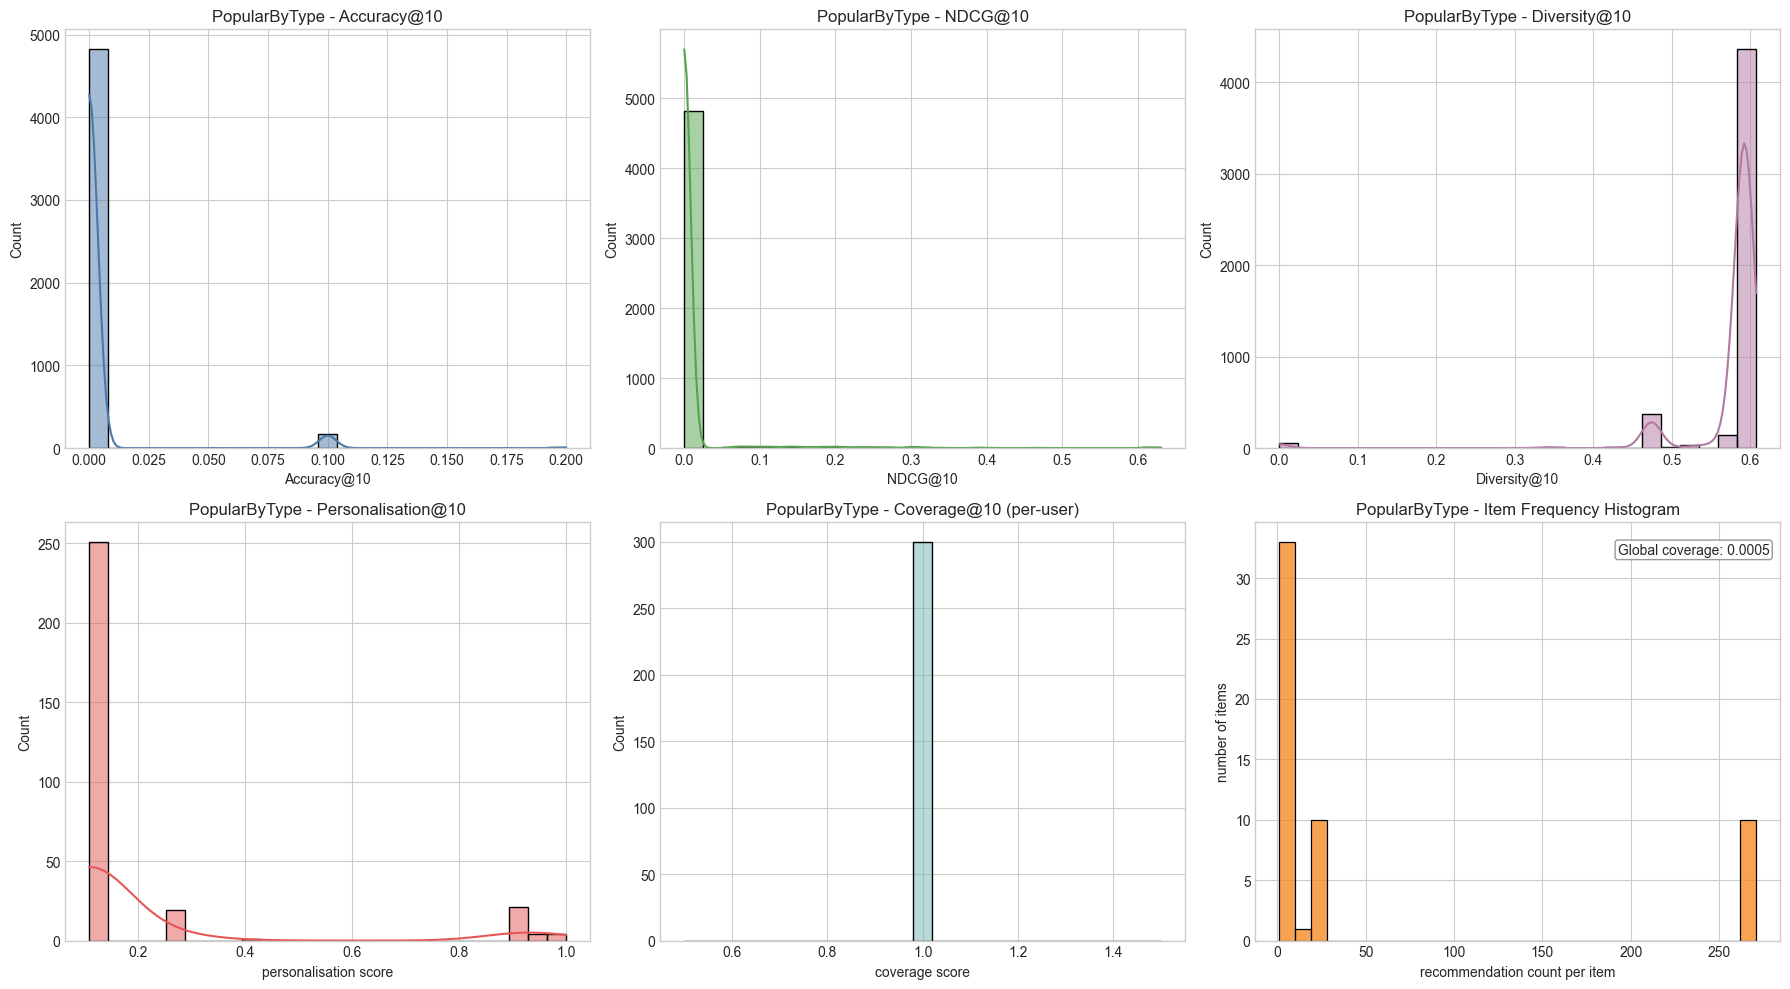

In [109]:
plot_model_diagnostics(type_eval_df, type_recs_by_user, "PopularByType", top_k=10, model=final_model)


These graphs show that most users still have very low accuracy and NDCG, so the recommendations are not very relevant. The model improves slightly by using wine type, but it still cannot match user preferences well.

The diversity is moderate, meaning there is some variation in recommendations, but personalisation is quite low, so many users still get similar items. Coverage is also very low, and the item frequency graph shows that a few wines are recommended very often, so the model still depends heavily on popular items within each type.


### Qualitative examples: 3 wine types

In [ ]:
train_with_type = trainval_pos.merge(wines[['WineID', 'Type']], on='WineID', how='left')
type_support = train_with_type['Type'].value_counts()

example_types = [t for t in type_support.index if t in final_model['type_rank']][:3]
print('Example wine types:', example_types)

for wine_type in example_types:
    recs = final_model['type_rank'][wine_type][:10]
    print(f'\nWine type: {wine_type}')
    display(
        wines[wines['WineID'].isin(recs)][['WineID', 'WineName', 'Type', 'Country']]
        .set_index('WineID')
        .loc[recs]
    )


Example wine types: ['Red', 'White', 'Sparkling']

Wine type: Red


,WineName,Type,Country
WineID,,,
179012,Cabernet Sauvignon,Red,United States
135825,Tignanello,Red,Italy
179014,Opus One,Red,United States
111395,Pauillac (Premier Grand Cru Classé),Red,France
135826,Sassicaia,Red,Italy
162499,Almaviva,Red,Chile
167421,Malbec Alta,Red,Argentina
179013,Red Blend,Red,United States
155290,Valbuena 5º,Red,Spain



Wine type: White


,WineName,Type,Country
WineID,,,
193479,Sauvignon Blanc,White,New Zealand
179070,Chardonnay,White,United States
193481,Sauvignon Blanc,White,New Zealand
101575,Alvarinho,White,Portugal
101568,Vinho Verde,White,Portugal
167462,Chardonnay,White,Argentina
193483,Private Bin Sauvignon Blanc,White,New Zealand
101589,Évora Colheita Branco,White,Portugal
193485,Sauvignon Blanc,White,New Zealand



Wine type: Sparkling


,WineName,Type,Country
WineID,,,
111391,Brut Champagne,Sparkling,France
111402,Cristal Brut Champagne (Millésimé),Sparkling,France
111393,Brut (Carte Jaune) Champagne,Sparkling,France
111394,Impérial Brut Champagne,Sparkling,France
111399,Special Cuvée Brut Aÿ Champagne,Sparkling,France
111490,Grande Cuvée Brut Champagne,Sparkling,France
111409,Brut Premier Champagne,Sparkling,France
111418,Grand Brut Champagne,Sparkling,France
111444,La Grande Année Brut Champagne,Sparkling,France


These recommendations show that the model correctly focuses on the user’s preferred wine type, since all items within each list belong to the same category (Red, White, or Sparkling). However, within each type, the same popular wines appear repeatedly, which means the model still relies heavily on popularity and does not provide much variety or deeper personalization.


## 11) Final comparison

This table contains only:
- Accuracy@K
- NDCG@K
- Diversity@K
- Personalisation@10
- Coverage


In [ ]:
popular_summary = pd.concat([global_summary, country_summary, type_summary], axis=0)
ordered_cols = [
    'Accuracy@5', 'Accuracy@10', 'Accuracy@20',
    'NDCG@5', 'NDCG@10', 'NDCG@20',
    'Diversity@5', 'Diversity@10', 'Diversity@20',
    'Personalisation@10', 'Coverage'
]
available_cols = [c for c in ordered_cols if c in popular_summary.columns]
popular_summary = popular_summary[available_cols]
display(popular_summary)


,Accuracy@5,Accuracy@10,Accuracy@20,NDCG@5,NDCG@10,NDCG@20,Diversity@5,Diversity@10,Diversity@20,Personalisation@10,Coverage
PopularGlobal,0.00468,0.00400,0.00315,0.006596,0.008424,0.010756,0.698213,0.665846,0.639617,0.025232,0.000169
PopularByCountry,0.01004,0.00802,0.00594,0.015353,0.018864,0.022558,0.123600,0.112646,0.118425,0.857921,0.003070
PopularByType,0.00412,0.00374,0.00328,0.005723,0.007598,0.010558,0.528560,0.574987,0.548592,0.199982,0.000755


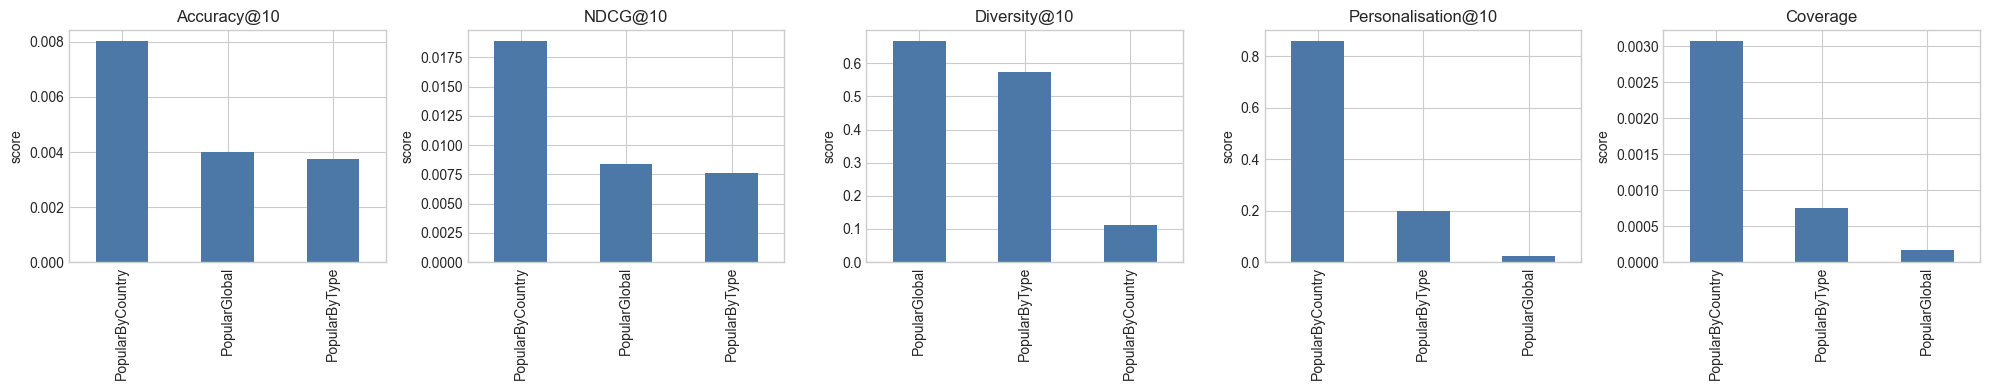

In [ ]:
plot_cols = [
    'Accuracy@10', 'NDCG@10', 'Diversity@10',
    'Personalisation@10', 'Coverage'
]
avail = [c for c in plot_cols if c in popular_summary.columns]

if avail:
    fig, axes = plt.subplots(1, len(avail), figsize=(4 * len(avail), 4))
    if len(avail) == 1:
        axes = [axes]
    for ax, col in zip(axes, avail):
        popular_summary[col].sort_values(ascending=False).plot(kind='bar', ax=ax, color='#4C78A8')
        ax.set_title(col)
        ax.set_ylabel('score')
    plt.tight_layout()
    plt.show()


These graphs show that the popular by country model performs the best in terms of accuracy and NDCG, which means it gives more relevant recommendations than the other two. It also has the highest personalisation and coverage, so it gives different recommendations to users and uses more items. Overall, for a popularity-based recommender, it does its job very well.

However, it has very low diversity, meaning the recommendations within each user are quite similar. On the other hand, the popular global model has the highest diversity but very low accuracy and almost no personalisation, while popular by type sits in the middle but still does not perform very well overall.


Coverage-focused histogram comparison across the three recommenders.


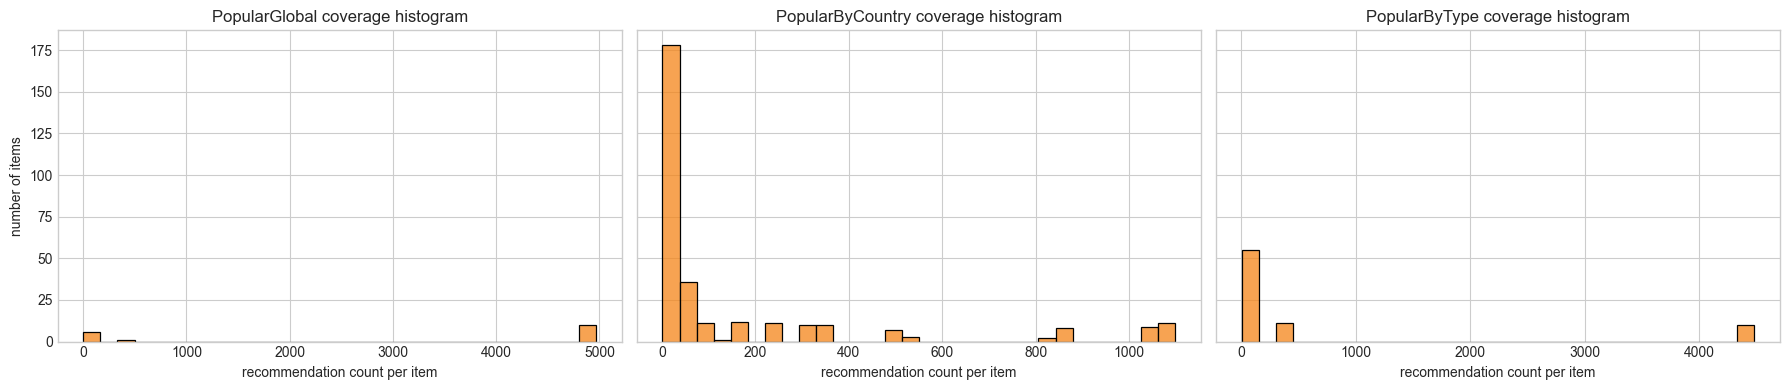

In [110]:
model_rec_maps = {
    'PopularGlobal': global_recs_by_user,
    'PopularByCountry': country_recs_by_user,
    'PopularByType': type_recs_by_user,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, (name, recs_map) in zip(axes, model_rec_maps.items()):
    all_items = []
    for _, recs in recs_map.items():
        all_items.extend(recs[:10])
    freq = pd.Series(all_items).value_counts() if all_items else pd.Series(dtype='int64')

    if freq.empty:
        ax.text(0.5, 0.5, 'No recs', ha='center', va='center')
    else:
        sns.histplot(freq.values, bins=30, kde=False, ax=ax, color='#F58518')
    ax.set_title(f'{name} coverage histogram')
    ax.set_xlabel('recommendation count per item')

axes[0].set_ylabel('number of items')
plt.tight_layout()
plt.show()


In [ ]:
global_eval_df.insert(0, 'Model', 'PopularGlobal')
country_eval_df.insert(0, 'Model', 'PopularByCountry')
type_eval_df.insert(0, 'Model', 'PopularByType')
popular_eval_all = pd.concat([global_eval_df, country_eval_df, type_eval_df], ignore_index=True)

popular_eval_path = RESULTS_DIR / 'nonpers_popular_eval_all.csv'
popular_summary_path = RESULTS_DIR / 'nonpers_popular_summary.csv'
popular_tuning_path = RESULTS_DIR / 'nonpers_popular_tuning.csv'

popular_eval_all.to_csv(popular_eval_path, index=False)
popular_summary.to_csv(popular_summary_path)
tuning_df.to_csv(popular_tuning_path, index=False)

print('Saved:')
print('-', popular_eval_path)
print('-', popular_summary_path)
print('-', popular_tuning_path)


Saved:
- /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/nonpers_popular_eval_all.csv
- /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/nonpers_popular_summary.csv
- /Users/sofiiaavetisian/Desktop/UNI/recsys/FINAL_WINE/wine-recommendation-system/data/results/nonpers_popular_tuning.csv


# 12) Saving the models

In [ ]:
# ---------- config ----------
EXPORT_DIR = PROJECT_ROOT / "non_personalised_recommenders" / "saved_models" / "popular"
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

TOP_N_GLOBAL = 500          # how many global items to export
TOP_N_PER_GROUP = 300       # how many items per country/type
# ---------------------------

def to_int_list(x, n=None):
    vals = [int(v) for v in x]
    return vals[:n] if n is not None else vals

# 1) Global popular
global_payload = {
    "model_name": "PopularGlobal",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "top_wine_ids": to_int_list(final_model["global_rank"], TOP_N_GLOBAL),
}
(EXPORT_DIR / "popular_global.json").write_text(
    json.dumps(global_payload, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

# 2) Popular by country
country_payload = {
    "model_name": "PopularByCountry",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "rankings_by_country": {
        str(country): to_int_list(rank, TOP_N_PER_GROUP)
        for country, rank in final_model["country_rank"].items()
    },
}
(EXPORT_DIR / "popular_by_country.json").write_text(
    json.dumps(country_payload, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

# 3) Popular by type
type_payload = {
    "model_name": "PopularByType",
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "rankings_by_type": {
        str(wine_type): to_int_list(rank, TOP_N_PER_GROUP)
        for wine_type, rank in final_model["type_rank"].items()
    },
}
(EXPORT_DIR / "popular_by_type.json").write_text(
    json.dumps(type_payload, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

# Optional: metadata lookup for frontend cards
meta = wines[["WineID", "WineName", "Type", "Country", "RegionName"]].copy()
meta["WineID"] = meta["WineID"].astype("int32")
meta.to_csv(EXPORT_DIR / "wine_metadata.csv", index=False)

print("Saved popular models to:", EXPORT_DIR)
print("-", EXPORT_DIR / "popular_global.json")
print("-", EXPORT_DIR / "popular_by_country.json")
print("-", EXPORT_DIR / "popular_by_type.json")
print("-", EXPORT_DIR / "wine_metadata.csv")
